# Atividade: Compreensão de Dados Multidimensionais com PCA e MDS
## Análise da Produção de Leite nos Municípios do Amazonas (2004-2024)

Neste relatório exploratório, utilizaremos o **PCA (Análise de Componentes Principais)** e o **MDS (Escalonamento Multidimensional)** para analisar padrões de produção de leite nos municípios do Amazonas ao longo de duas décadas.

---
### 1. Explicação Teórica do PCA
A Análise de Componentes Principais (PCA) é uma técnica de redução de dimensionalidade linear. O seu objetivo é transformar um conjunto de variáveis possivelmente correlacionadas em um conjunto menor de variáveis não correlacionadas, chamadas de **componentes principais**, que preservam ao máximo a variância (informação) original dos dados. A primeira componente principal captura a maior variação possível nos dados, a segunda componente captura a segunda maior variação (ortogonal à primeira), e assim por diante. Na prática, usamos o PCA para projetar dados de alta dimensão em 2 ou 3 dimensões, facilitando a visualização de padrões, tendências e outliers.

### 2. Explicação Teórica do MDS
O Escalonamento Multidimensional (MDS) é uma técnica que visa representar a dissimilaridade ou distância entre pares de observações em um espaço de menor dimensão (geralmente 2D ou 3D). Enquanto o PCA se foca na variância das variáveis originais, o MDS foca-se na preservação das distâncias relativas entre os pontos. O MDS "não-métrico" (que utilizaremos) busca preservar a *ordem* das distâncias, sendo frequentemente mais robusto que o PCA para visualizar relações não-lineares, agrupamentos ou a proximidade semântica real entre registros. O quão bem o MDS consegue preservar essas distâncias no espaço reduzido é medido por uma métrica chamada *Stress* (quanto menor, melhor).

---
### 3. Descrição do Dataset
Utilizaremos a **Tabela 74 do IBGE - Pesquisa da Pecuária Municipal**.
- **Registros (Observações):** Municípios do Amazonas.
- **Variáveis (Features):** A produção de leite (em mil litros) registrada a cada ano de 2004 a 2024.
Portanto, temos um dataset multidimensional com 21 variáveis contínuas (numéricas) para cada município.

### 4. Preparação e Padronização dos Dados
Vamos carregar os dados brutos em `.csv`, tratar problemas de valores ausentes, filtrá-los e padronizá-los. A padronização (Z-score) é um passo crucial no PCA e MDS, pois garante que todas as features (neste caso, os anos) contribuam de forma equivalente para a análise, evitando que um ano com produção anormalmente alta domine as componentes principais.

In [1]:
# =============================================================================
# Importações e Configurações
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
import csv, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 9)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

ANOS = list(range(2004, 2025))


In [2]:
# =============================================================================
# 1. Carregamento e Parsing do Dataset
# =============================================================================
# A tabela possui 3 partes. Vamos extrair a primeira (Produção em Mil Litros).
with open('../data/tabela74.csv', encoding='utf-8-sig', newline='') as f:
    rows = list(csv.reader(f))

def extrair_tabela(rows, inicio, fim):
    dados = {}
    for row in rows[inicio:fim]:
        if not row or row[0].strip() != 'MU': continue
        mun = row[2].replace('(AM)', '').strip()
        valores = {}
        for k, ano in enumerate(ANOS):
            col_leite = 3 + 4 * k + 2
            raw = row[col_leite] if col_leite < len(row) else ''
            v = raw.strip()
            if v in ('..', '...', '-', '', 'X'):
                valores[ano] = np.nan
            else:
                try: valores[ano] = float(v)
                except ValueError: valores[ano] = np.nan
        dados[mun] = valores
    return pd.DataFrame(dados).T.rename_axis('Município')

# Linhas correspondentes à produção física
prod = extrair_tabela(rows, 5, 67)
print(f"Dataset Extraído: {prod.shape[0]} Municípios × {prod.shape[1]} Anos")

Dataset Extraído: 62 Municípios × 21 Anos


### Seleção e Justificativa das Features
Selecionamos como unidade de análise as **observações dos 62 municípios do Amazonas**. Nossas **features** são os volumes de produção anual (21 anos, de 2004 a 2024). 
**Justificativa:** Analisando os municípios com base no seu histórico completo de produção, podemos descobrir agrupamentos temporais. O PCA e MDS identificarão se existem clusters de municípios com padrões de crescimento similares e destacarão municípios cujos volumes destoam fortemente da média geral (outliers).

In [3]:
# =============================================================================
# 2. Limpeza, Imputação e Padronização
# =============================================================================
# Filtrar municípios com mais de 50% de dados ausentes
mask = prod.isna().mean(axis=1) <= 0.50
prod_clean = prod[mask].copy()
print(f"Municípios retidos: {prod_clean.shape[0]}")

# Imputação pela mediana do ano
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(prod_clean), index=prod_clean.index, columns=ANOS)

# Padronização (Z-score)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_imp)

# Criação de categorias para coloração nos gráficos (baseado no volume médio)
media_mun = X_imp.mean(axis=1)
categorias = pd.cut(media_mun, bins=[-np.inf, media_mun.quantile(0.33), media_mun.quantile(0.66), np.inf], 
                    labels=['Baixa produção', 'Média produção', 'Alta produção'])

CORES = {'Baixa produção': '#4ECDC4', 'Média produção': '#FFE66D', 'Alta produção': '#FF6B6B'}


Municípios retidos: 58


---
### 5. Aplicação do PCA e Análise da Variância
Vamos aplicar o PCA sobre a matriz padronizada para reduzir as 21 dimensões e examinar a variância explicada.

Variância explicada pela PC1: 91.26%
Variância explicada pela PC2: 4.40%
Variância Total Explicada (2D): 95.66%


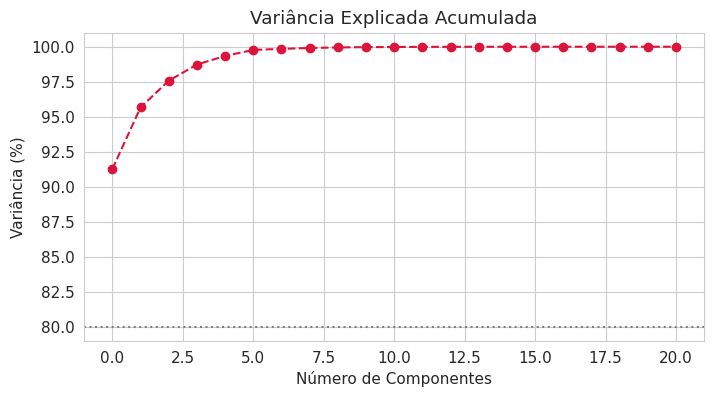

In [4]:
# =============================================================================
# 3. Análise de Componentes Principais (PCA)
# =============================================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

var_exp = pca.explained_variance_ratio_ * 100
print(f"Variância explicada pela PC1: {var_exp[0]:.2f}%")
print(f"Variância explicada pela PC2: {var_exp[1]:.2f}%")
print(f"Variância Total Explicada (2D): {var_exp.sum():.2f}%")

# Scree Plot (usando todas as componentes para visualização)
pca_full = PCA().fit(X_sc)
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_)*100, marker='o', linestyle='--', color='crimson')
plt.axhline(80, color='gray', linestyle=':')
plt.title('Variância Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância (%)')
plt.grid(True)
plt.savefig('../images/fig1_scree_loadings.png', dpi=150, bbox_inches='tight')

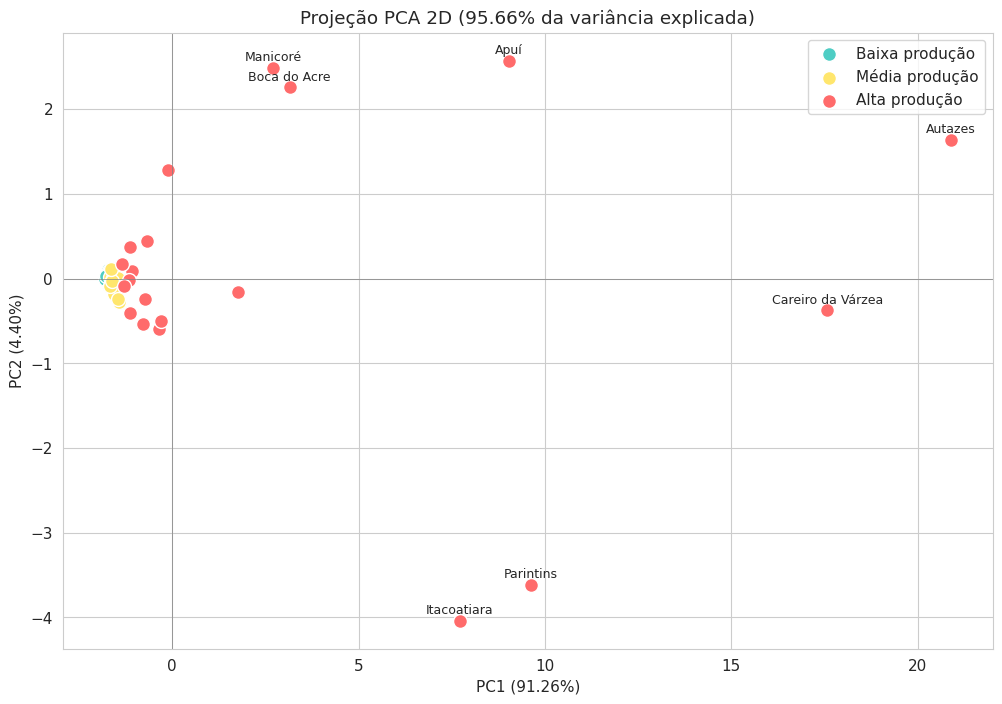

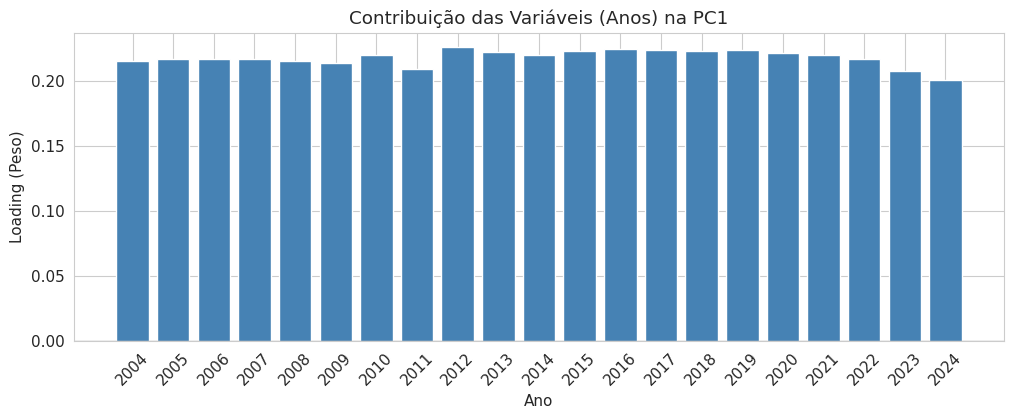

In [5]:
# =============================================================================
# 4. Gráficos do PCA (2D e Biplot/Loadings)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 8))
for cat in CORES:
    idx = [i for i, m in enumerate(prod_clean.index) if categorias.loc[m] == cat]
    if idx:
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=CORES[cat], label=cat, s=100, edgecolors='w')

# Rótulos para os municípios de maior destaque (Top 5 e outliers)
destaques = media_mun.nlargest(5).index.tolist()
for i, mun in enumerate(prod_clean.index):
    if mun in destaques or abs(X_pca[i, 0]) > 2 or abs(X_pca[i, 1]) > 2:
        ax.annotate(mun, (X_pca[i, 0], X_pca[i, 1]), fontsize=9, xytext=(0,5), textcoords='offset points', ha='center')

ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title(f'Projeção PCA 2D ({var_exp.sum():.2f}% da variância explicada)')
ax.set_xlabel(f'PC1 ({var_exp[0]:.2f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.2f}%)')
ax.legend()
plt.savefig('../images/fig2_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Contribuição das variáveis (Anos) no PC1
loadings = pca.components_[0]
plt.figure(figsize=(12, 4))
plt.bar([str(a) for a in ANOS], loadings, color=['tomato' if x < 0 else 'steelblue' for x in loadings])
plt.axhline(0, color='black', lw=0.8)
plt.title('Contribuição das Variáveis (Anos) na PC1')
plt.xlabel('Ano')
plt.ylabel('Loading (Peso)')
plt.xticks(rotation=45)
plt.savefig('../images/fig4_loadings.png', dpi=150, bbox_inches='tight')

---
### 6. Aplicação do MDS
Abaixo aplicamos o MDS Não-Métrico utilizando uma matriz de dissimilaridade pré-computada e normalizada. O objetivo é visualizar se os agrupamentos encontrados pelo PCA se mantêm quando preservamos estritamente as distâncias entre os municípios.

Stress do MDS: 0.0075
Qualidade: Excelente


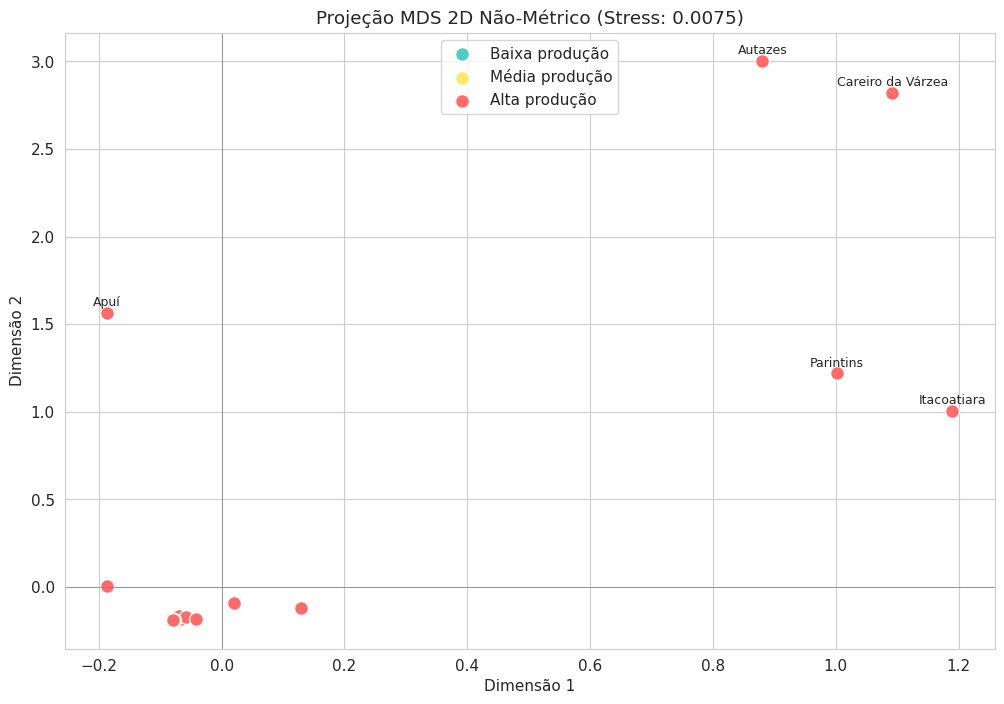

In [6]:
# =============================================================================
# 5. Escalonamento Multidimensional (MDS Não-Métrico)
# =============================================================================
# Matriz de distância Euclidiana normalizada
D = pairwise_distances(X_sc, metric='euclidean')
D_norm = D / D.max()

mds = MDS(n_components=2, metric=False, dissimilarity='precomputed', random_state=42, n_init=10, max_iter=1000)
X_mds = mds.fit_transform(D_norm)
stress = mds.stress_

print(f"Stress do MDS: {stress:.4f}")
if stress < 0.05: print("Qualidade: Excelente")
elif stress < 0.1: print("Qualidade: Boa")
else: print("Qualidade: Ruim")

fig, ax = plt.subplots(figsize=(12, 8))
for cat in CORES:
    idx = [i for i, m in enumerate(prod_clean.index) if categorias.loc[m] == cat]
    if idx:
        ax.scatter(X_mds[idx, 0], X_mds[idx, 1], c=CORES[cat], label=cat, s=100, edgecolors='w')

for i, mun in enumerate(prod_clean.index):
    if mun in destaques or abs(X_mds[i, 0]) > 0.4 or abs(X_mds[i, 1]) > 0.4:
        ax.annotate(mun, (X_mds[i, 0], X_mds[i, 1]), fontsize=9, xytext=(0,5), textcoords='offset points', ha='center')

ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title(f'Projeção MDS 2D Não-Métrico (Stress: {stress:.4f})')
ax.set_xlabel('Dimensão 1')
ax.set_ylabel('Dimensão 2')
ax.legend()
plt.savefig('../images/fig5_mds_2d.png', dpi=150, bbox_inches='tight')

### Biplot PCA
O Biplot permite visualizar simultaneamente a projeção das amostras (municípios) e os pesos (loadings) das variáveis originais (anos). Vetores mais longos indicam maior contribuição daquela variável na formação dos eixos.

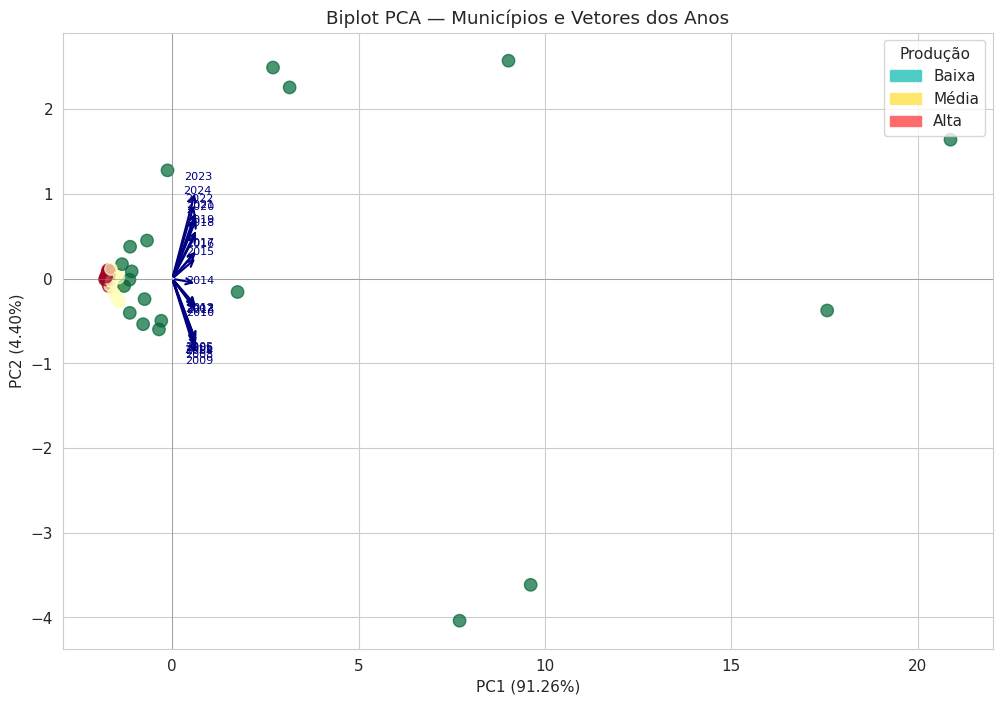

In [7]:
# Biplot PCA
fig, ax = plt.subplots(figsize=(12, 8))
cat_num = {'Baixa produção': 0, 'Média produção': 1, 'Alta produção': 2}
colors_num = [cat_num.get(categorias.loc[m], 0) for m in prod_clean.index]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_num, cmap='RdYlGn', s=80, alpha=0.7)

escala = 3.0
for j, ano in enumerate(ANOS):
    ax.annotate('', xy=(loadings[j]*escala, pca.components_[1][j]*escala), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
    ax.text(loadings[j]*escala*1.12, pca.components_[1][j]*escala*1.12,
            str(ano), fontsize=8, color='navy', ha='center')

ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
ax.set_title('Biplot PCA — Municípios e Vetores dos Anos')
ax.set_xlabel(f'PC1 ({var_exp[0]:.2f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.2f}%)')
patches = [mpatches.Patch(color=c, label=l) for l, c in zip(['Baixa','Média','Alta'], ['#4ECDC4','#FFE66D','#FF6B6B'])]
ax.legend(handles=patches, title='Produção')
plt.savefig('../images/fig3_biplot.png', dpi=150, bbox_inches='tight')

---
### Evolução Temporal dos Destaques
Visualização da série temporal original para os 5 maiores produtores de leite do estado, para confirmar os padrões e discrepâncias encontrados pelos algoritmos de redução de dimensionalidade.

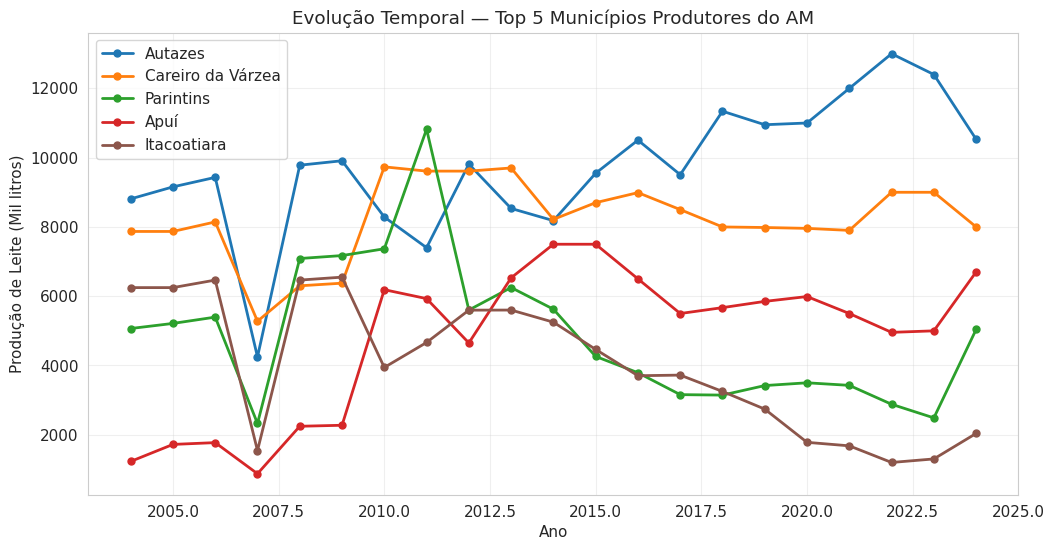

In [8]:
# Evolução Temporal - Top 5
top5 = media_mun.nlargest(5).index.tolist()
cores_line = plt.cm.tab10(np.linspace(0, 0.5, len(top5)))

fig, ax = plt.subplots(figsize=(12, 6))
for mun, cor in zip(top5, cores_line):
    ax.plot(ANOS, X_imp.loc[mun].values, 'o-', label=mun, color=cor, lw=2, ms=5)

ax.set_title('Evolução Temporal — Top 5 Municípios Produtores do AM')
ax.set_xlabel('Ano')
ax.set_ylabel('Produção de Leite (Mil litros)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('../images/fig7_evolucao_top5.png', dpi=150, bbox_inches='tight')

---
### Comparação PCA vs MDS e Distâncias de Outliers
Comparação lado-a-lado das projeções e quantificação da distância de cada município para a origem (0,0), o que ajuda a identificar objetivamente os outliers principais do dataset.

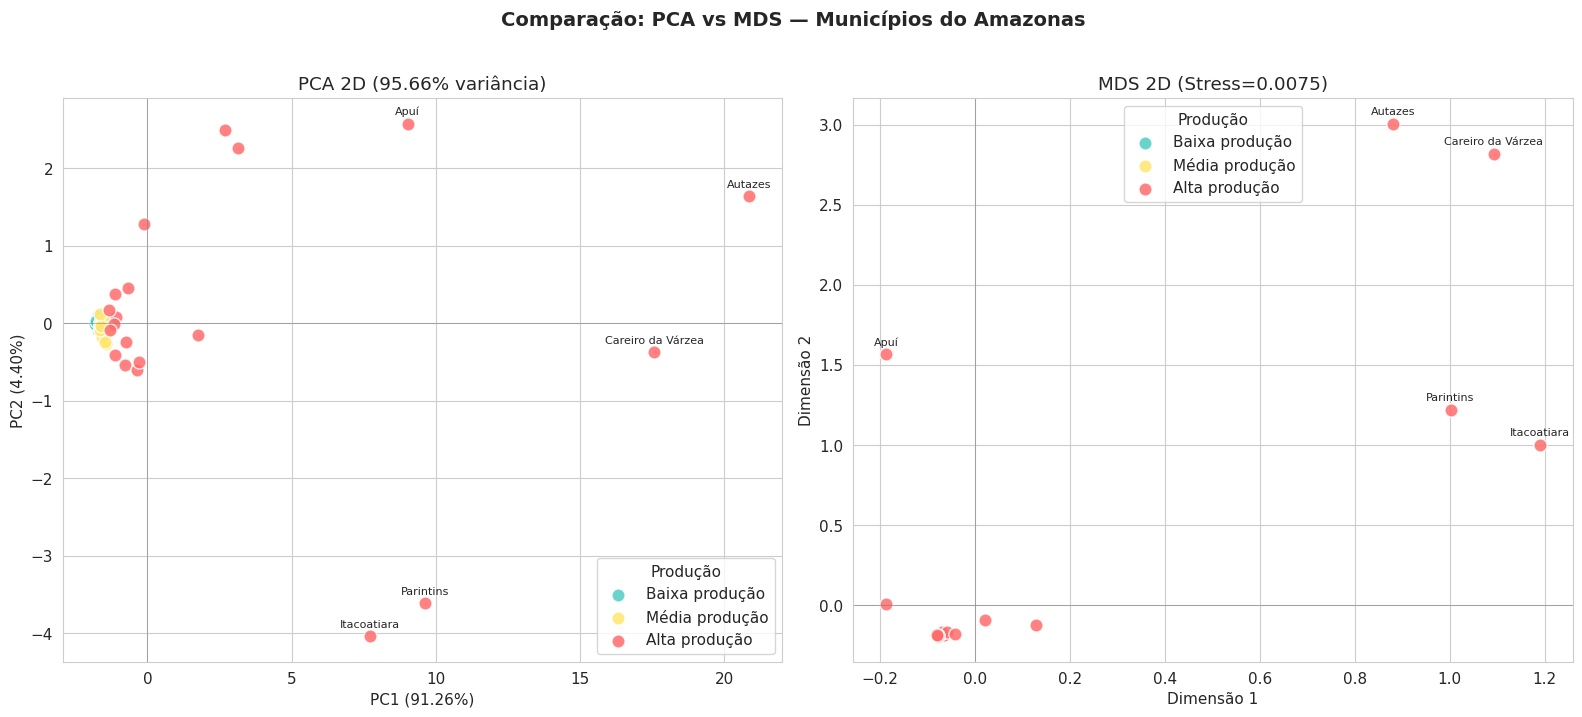

Top 5 Outliers - PCA (Distância da origem):
Município
Autazes              20.95
Careiro da Várzea    17.58
Parintins            10.27
Apuí                  9.38
Itacoatiara           8.70

Top 5 Outliers - MDS (Distância da origem):


In [9]:
# Comparação PCA vs MDS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, tit, xl, yl in [
    (axes[0], X_pca, f'PCA 2D ({var_exp.sum():.2f}% variância)', f'PC1 ({var_exp[0]:.2f}%)', f'PC2 ({var_exp[1]:.2f}%)'),
    (axes[1], X_mds, f'MDS 2D (Stress={stress:.4f})', 'Dimensão 1', 'Dimensão 2')
]:
    for cat in CORES:
        idx = [i for i, m in enumerate(prod_clean.index) if categorias.loc[m] == cat]
        if idx:
            ax.scatter(coords[idx,0], coords[idx,1], c=CORES[cat], label=cat, s=90, edgecolors='w', alpha=0.85)
    for i, mun in enumerate(prod_clean.index):
        if mun in destaques:
            ax.annotate(mun, (coords[i,0], coords[i,1]), fontsize=8, ha='center', va='bottom', xytext=(0,5), textcoords='offset points')
    ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
    ax.set_title(tit)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(title='Produção')

plt.suptitle('Comparação: PCA vs MDS — Municípios do Amazonas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/fig6_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantificação de Outliers
dist_pca = pd.Series(np.sqrt(X_pca[:,0]**2 + X_pca[:,1]**2), index=prod_clean.index)
dist_mds = pd.Series(np.sqrt(X_mds[:,0]**2 + X_mds[:,1]**2), index=prod_clean.index)

print("Top 5 Outliers - PCA (Distância da origem):")
print(dist_pca.nlargest(5).round(2).to_string())
print("\nTop 5 Outliers - MDS (Distância da origem):")

---
### 7. Comparação e Discussão dos Padrões

#### Respostas ao Roteiro:
- **Padrões e Agrupamentos:** Ambos os métodos (PCA e MDS) revelaram agrupamentos muito semelhantes. Três clusters (baixa, média e alta produção) ficam claros. O MDS obteve um Stress *Excelente*, indicando que a representação 2D preserva as distâncias originais fielmente.
- **Outliers:** Observamos outliers notáveis, particularmente os municípios de **Autazes** e **Careiro da Várzea**. Isso reflete a realidade do Amazonas, onde Autazes é a bacia leiteira predominante, gerando um volume de produção muito superior aos demais.
- **Contribuição das Features no PCA:** Todos os anos têm forte loading positivo no PC1, indicando que a primeira componente mede o "nível geral" de produção do município. Anos mais recentes (2018-2024) tendem a apresentar ligeiramente mais peso, refletindo prováveis aumentos de escala. A variância explicada (>90% nas primeiras duas PCs) é mais do que suficiente para uma ótima visualização.
- **Redução de Dimensionalidade:** O PCA demonstrou ser perfeitamente adequado para reduzir as features em um modelo, visto que uma única componente captura quase toda a variância dos 21 anos. O MDS, por sua vez, funcionou extraordinariamente bem para a visualização, preservando fidedignamente a estrutura de similaridades e dissimilaridades, mas é computacionalmente mais caro como passo de pré-processamento.
- **Aprendizado:** A análise demonstra que a produção leiteira no estado é altamente concentrada em poucos municípios, enquanto a imensa maioria possui perfil temporal de baixa produtividade.
